# Agrupamento de dados

**Francisco Aparecido Rodrigues**  
Universidade de São Paulo, São Carlos, Brasil  
<https://sites.icmc.usp.br/francisco>  

<hr>

Nas aulas anteriores, trabalhamos com **aprendizado supervisionado**: tínhamos os atributos $\mathbf{x}$ e também um rótulo conhecido $y$ (a classe, no caso da classificação, ou um valor numérico, no caso da regressão), e o objetivo era aprender uma função $f$ tal que $y \approx f(\mathbf{x})$.

No **agrupamento** (clustering), a situação é diferente: temos apenas os atributos $\mathbf{x}$, **sem** nenhum rótulo. O objetivo é descobrir uma estrutura de grupos (clusters) nos dados, de forma que:

- observações dentro do **mesmo** grupo sejam o mais **similares** possível entre si;
- observações em grupos **diferentes** sejam o mais **distintas** possível.

Por isso, clustering é um exemplo de **aprendizado não supervisionado**. Alguns exemplos de uso:

- segmentação de clientes (marketing), agrupando por padrão de consumo;
- agrupamento de documentos ou notícias por assunto;
- identificação de comunidades em redes sociais;
- compressão de imagens (agrupar cores parecidas);
- detecção de subtipos de uma doença a partir de exames clínicos.

Nesta aula, vamos estudar dois algoritmos clássicos de agrupamento (**k-means** e **agrupamento hierárquico**) e como avaliar a qualidade de um agrupamento.

Inicialmente, vamos gerar dados artificiais usando funções específicas da biblioteca scikit-learn. Uma delas é a `make_blobs` (https://scikit-learn.org/stable/modules/generated/sklearn.datasets.make_blobs.html), que gera grupos de pontos com formato aproximadamente esférico (globular) ao redor de centros sorteados aleatoriamente — um cenário ideal para o k-means, como veremos.

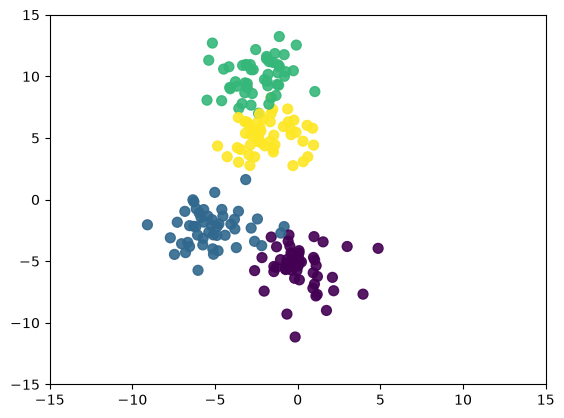

In [37]:
# importa as bibliotecas básicas
from sklearn.datasets import make_blobs
import numpy as np
import matplotlib.pyplot as plt

k = 4    # número de clusters
n = 200  # número de pontos
data = make_blobs(n_samples=n, n_features=2, centers=k, cluster_std=1.5, random_state=50)
X = data[0]       # atributos das observações
labels = data[1]  # classe conhecida inicialmente (usada aqui só para visualização/avaliação)

# mostra os dados
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', s=50, alpha=0.9)
plt.xlim(-15, 15)
plt.ylim(-15, 15)
plt.show()

As cores dos pontos acima representam os clusters originais (conhecidos apenas porque geramos os dados artificialmente — na prática, esses rótulos não estariam disponíveis; é justamente isso que o algoritmo de agrupamento tenta descobrir).

## k-means

O método **k-means** é o algoritmo de agrupamento mais popular. A ideia central é simples: dado um número de clusters $k$ (definido pelo usuário), o algoritmo tenta encontrar $k$ centros (centróides) $\bar{\mathbf{x}}_{C_1}, \ldots, \bar{\mathbf{x}}_{C_k}$ que minimizem a soma das distâncias quadráticas de cada ponto ao centróide do seu cluster:
$$
WCSS=\sum_{i=1}^{k} \sum_{\mathbf{x}\in C_i} \lVert \mathbf{x}-\bar{\mathbf{x}}_{C_i} \rVert^2,
$$
onde $C_i$ é o conjunto de pontos atribuídos ao cluster $i$. Essa quantidade é chamada de **WCSS** (*within-cluster sum of squares*, soma dos quadrados dentro dos clusters). Quanto menor, mais compactos (mais "parecidos entre si") são os pontos dentro de cada cluster.

O algoritmo funciona de forma iterativa (algoritmo de Lloyd):

1. **Inicialização**: escolhe $k$ centróides iniciais (por exemplo, sorteando $k$ pontos dos dados);
2. **Atribuição**: cada ponto é atribuído ao cluster cujo centróide está mais próximo (distância euclidiana);
3. **Atualização**: cada centróide é recalculado como a média dos pontos atribuídos a ele;
4. Repete os passos 2 e 3 até que as atribuições não mudem mais (convergência).

Esse processo sempre converge, mas não necessariamente para o **mínimo global** de WCSS. Isto é, pode ficar preso em um mínimo local que depende de onde os centróides começaram (voltaremos a esse ponto mais adiante). Veja a documentação da implementação do scikit-learn em https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html

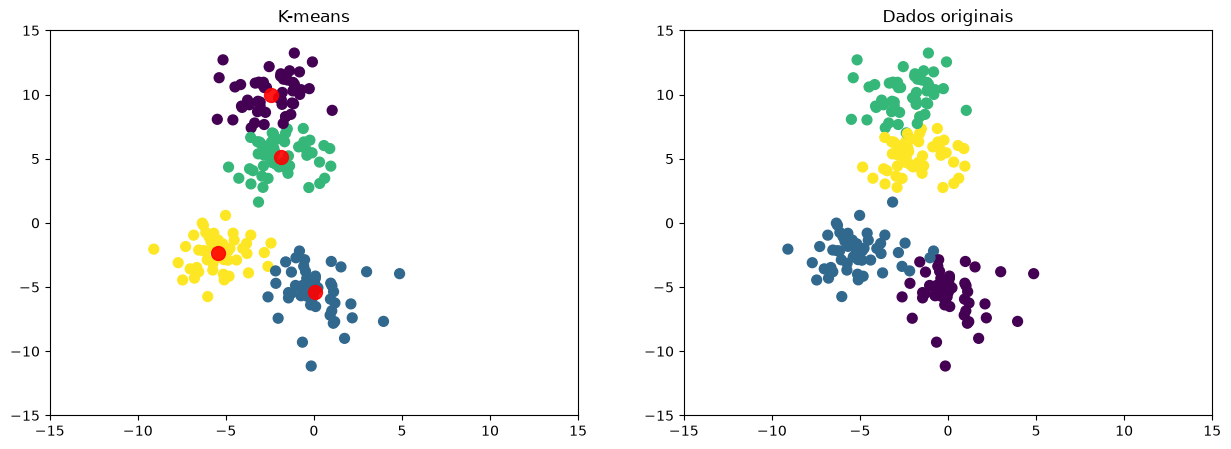

In [38]:
from sklearn.cluster import KMeans

k = 4  # número de clusters a serem identificados
# define o método com k clusters
kmeans = KMeans(n_clusters=k, random_state=42)

# realiza o ajuste considerando os dados X
kmeans.fit(X)

# faz a predição, identificando os clusters
y_km = kmeans.predict(X)

# define o tamanho da figura
plt.figure(figsize=(15, 5))

# mostra o primeiro gráfico
plt.subplot(1, 2, 1)
plt.scatter(X[:, 0], X[:, 1], c=y_km, cmap='viridis', s=50)
plt.xlim(-15, 15)
plt.ylim(-15, 15)
plt.title('K-means')
centers = kmeans.cluster_centers_

# mostra os centróides obtidos
plt.scatter(centers[:, 0], centers[:, 1], c='red', s=100, alpha=0.9)  # centro de cada cluster

# mostra o segundo gráfico
plt.subplot(1, 2, 2)
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', s=50)
plt.xlim(-15, 15)
plt.ylim(-15, 15)
plt.title('Dados originais')
plt.show()

Como os dados foram gerados com $k=4$ centros e o algoritmo também usou $k=4$, o resultado tende a reproduzir bem os grupos originais. Mas, na prática, **não sabemos** o número real de clusters — é preciso estimá-lo a partir dos próprios dados.

Podemos estimar o número ideal de clusters usando o **método do cotovelo** (*elbow method*). A ideia é calcular o WCSS para vários valores de $k$ e observar como ele diminui: à medida que $k$ aumenta, o WCSS sempre diminui (no limite, com $k$ igual ao número de pontos, o WCSS é zero — cada ponto é seu próprio cluster). O que buscamos é o valor de $k$ a partir do qual aumentar o número de clusters passa a trazer pouco ganho adicional, isto é, o ponto onde a curva "dobra", parecendo um cotovelo. No scikit-learn, o WCSS de um modelo já ajustado está disponível no atributo `kmeans.inertia_`.

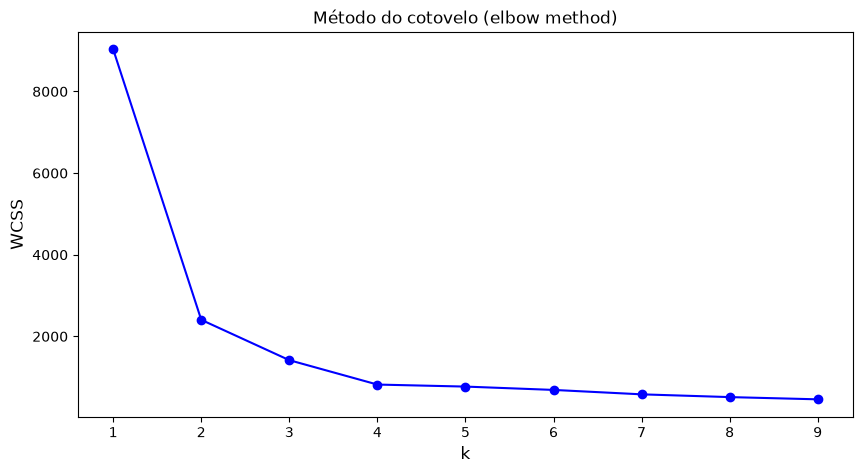

In [39]:
from scipy.spatial.distance import cdist

WCSS = []
K = range(1, 10)
# considerando diversos valores de k
for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X)
    # kmeans.inertia_ é o WCSS: a soma das distâncias quadráticas de cada
    # ponto ao centróide do cluster ao qual foi atribuído
    WCSS.append(kmeans.inertia_)

# mostra os resultados
plt.figure(figsize=(10, 5))
plt.plot(K, WCSS, '-bo')
plt.xlabel('k', fontsize=12)
plt.ylabel('WCSS', fontsize=12)
plt.title('Método do cotovelo (elbow method)')
plt.show()

Para deixar claro de onde vem o valor de `kmeans.inertia_`, podemos calculá-lo manualmente usando a função `cdist` para medir a distância de cada ponto ao seu centróide, e comparar com o valor retornado pelo scikit-learn.

In [40]:
k = 4
kmeans = KMeans(n_clusters=k, random_state=42).fit(X)
y_km = kmeans.predict(X)
centers = kmeans.cluster_centers_

# distância euclidiana ao quadrado de cada ponto ao seu respectivo centróide
wcss_manual = sum(
    cdist([X[i]], [centers[y_km[i]]], metric='sqeuclidean')[0, 0]
    for i in range(len(X))
)

print('WCSS calculado manualmente:', wcss_manual)
print('kmeans.inertia_:           ', kmeans.inertia_)

WCSS calculado manualmente: 819.6638802896247
kmeans.inertia_:            819.6638802896243


No gráfico do método do cotovelo, o "cotovelo" aparece por volta de k=4, exatamente o número de clusters usado para gerar os dados. Este é um bom sinal de que o método está funcionando como esperado. Se assumirmos, por exemplo, que há apenas três clusters (uma escolha propositalmente diferente do valor ideal, para ilustrar o efeito):

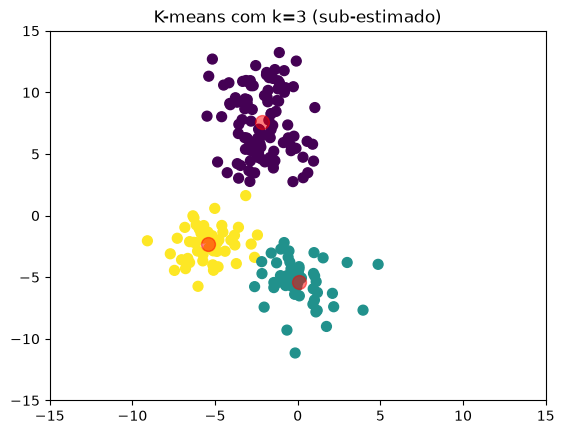

In [41]:
from sklearn.cluster import KMeans

# número de clusters
k = 3
kmeans = KMeans(n_clusters=k, random_state=42)
kmeans.fit(X)
y_km = kmeans.predict(X)

plt.scatter(X[:, 0], X[:, 1], c=y_km, cmap='viridis', s=50)
centers = kmeans.cluster_centers_

plt.scatter(centers[:, 0], centers[:, 1], c='red', s=100, alpha=0.5)
plt.xlim(-15, 15)
plt.ylim(-15, 15)
plt.title('K-means com k=3 (sub-estimado)')
plt.show()

Note que, com $k=3$, dois dos quatro grupos originais acabam sendo fundidos em um único cluster. O algoritmo faz o melhor que pode com o número de clusters que foi informado, mesmo que esse número não reflita a estrutura real dos dados.

No algoritmo k-means, o agrupamento final pode depender da posição inicial dos centróides (passo 1 do algoritmo descrito acima), pois o algoritmo pode convergir para um mínimo local diferente dependendo de onde começou. Abaixo, forçamos esse comportamento usando `init='random'` (centróides iniciais sorteados aleatoriamente, sem otimização) e `n_init=1` (uma única tentativa, sem repetir com sementes diferentes), para deixar visível a variação entre execuções. O centro de cada cluster é mostrado em vermelho.

**Observação**: por padrão (sem esses parâmetros), a implementação do scikit-learn já lida com esse problema automaticamente: ela usa a inicialização inteligente `k-means++` (que espalha os centróides iniciais de forma mais criteriosa, em vez de puramente aleatória) e repete o algoritmo várias vezes com sementes diferentes (`n_init`), mantendo o resultado com menor WCSS. Ou seja, no uso comum do k-means, o usuário não precisa se preocupar manualmente com esse detalhe. Veja a documentação em https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html

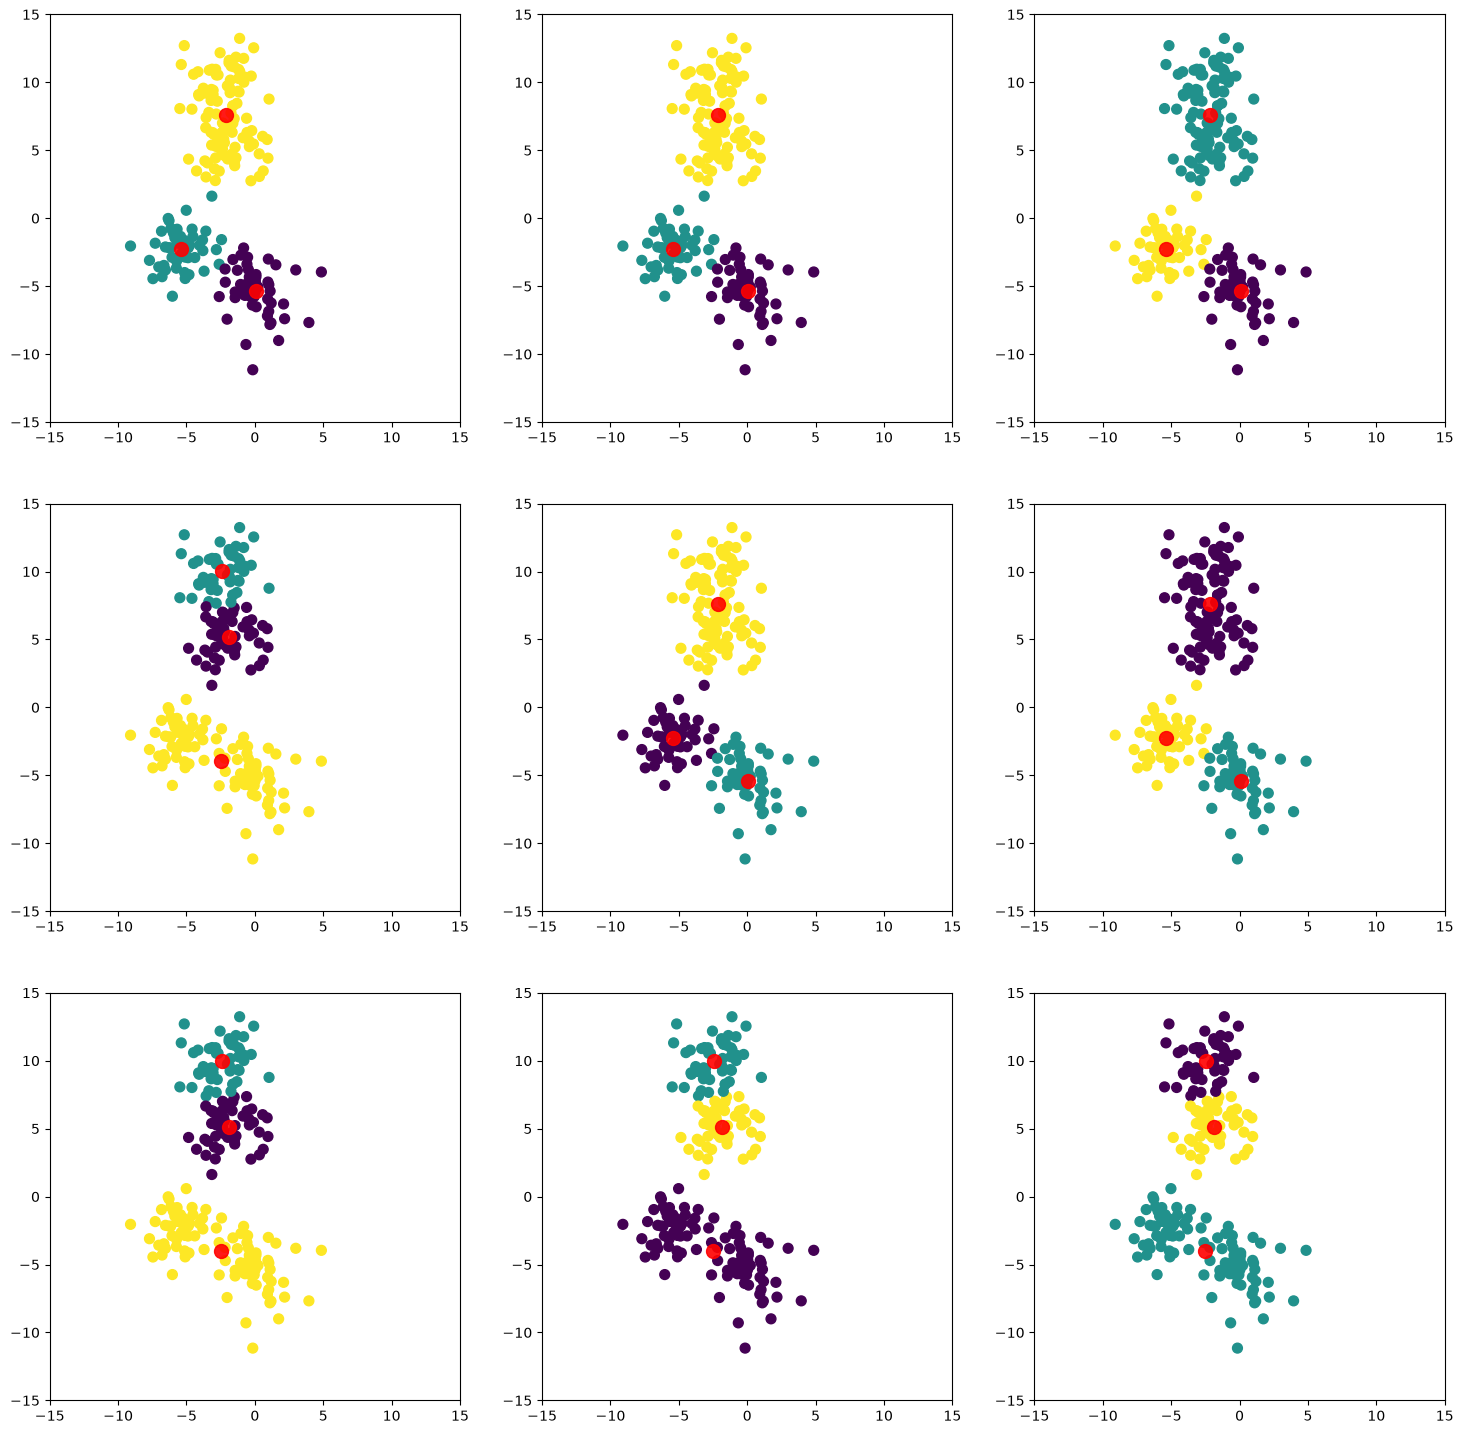

In [42]:
from sklearn.cluster import KMeans

k = 3  # número de clusters
plt.figure(figsize=(18, 18))
# mostra 9 execuções diferentes do algoritmo no mesmo conjunto de dados,
# cada uma partindo de uma inicialização aleatória diferente
for s in np.arange(1, 10):
    kmeans = KMeans(n_clusters=k, init='random', n_init=1, random_state=s)
    kmeans.fit(X)
    y_km = kmeans.predict(X)
    plt.subplot(3, 3, s)
    plt.scatter(X[:, 0], X[:, 1], c=y_km, cmap='viridis', s=50)
    centers = kmeans.cluster_centers_
    plt.scatter(centers[:, 0], centers[:, 1], c='red', s=100, alpha=0.9)
    plt.xlim(-15, 15)
    plt.ylim(-15, 15)
plt.show()

Note que, apesar da inicialização aleatória e sem repetição, o resultado é razoavelmente parecido entre as execuções nesse exemplo (os clusters são bem separados). Em conjuntos de dados com clusters mais próximos uns dos outros ou mais sobrepostos, a diferença entre execuções tende a ser mais visível, o que reforça a importância de usar `k-means++` e `n_init` maior que 1 (os valores padrão do scikit-learn) na prática.

O k-means assume implicitamente que os clusters têm formato aproximadamente **esférico/globular** e tamanhos parecidos — afinal, ele atribui cada ponto ao centróide mais próximo, o que naturalmente gera fronteiras retas (na verdade, um diagrama de Voronoi) entre clusters. Quando os clusters têm formato **não convexo** (por exemplo, entrelaçados, em forma de lua ou espiral), o k-means tende a falhar, pois nesses casos "mais próximo do centróide" não é um bom critério de similaridade. Vamos ver um exemplo clássico: dados gerados no formato de duas "luas" entrelaçadas (`make_moons`).

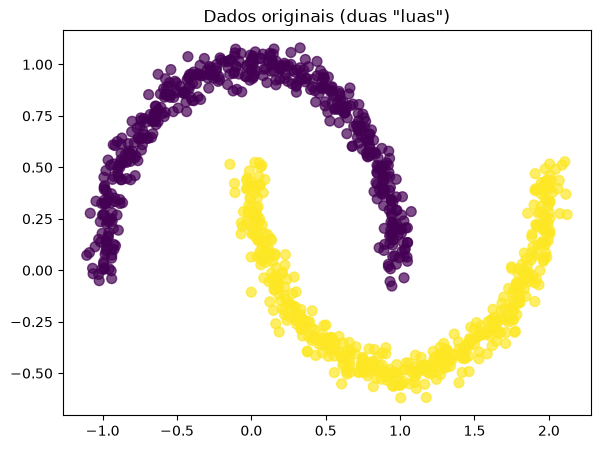

In [43]:
from sklearn import cluster, datasets

plt.figure(figsize=(15, 5))

# número de observações
n_samples = 1000
# gera os dados
data = datasets.make_moons(n_samples=n_samples, noise=.05, random_state=42)
X = data[0]
labels = data[1]
plt.subplot(1, 2, 1)
plt.scatter(X[:, 0], X[:, 1], c=data[1], cmap='viridis', s=50, alpha=0.7)
plt.title('Dados originais (duas "luas")')
plt.show()

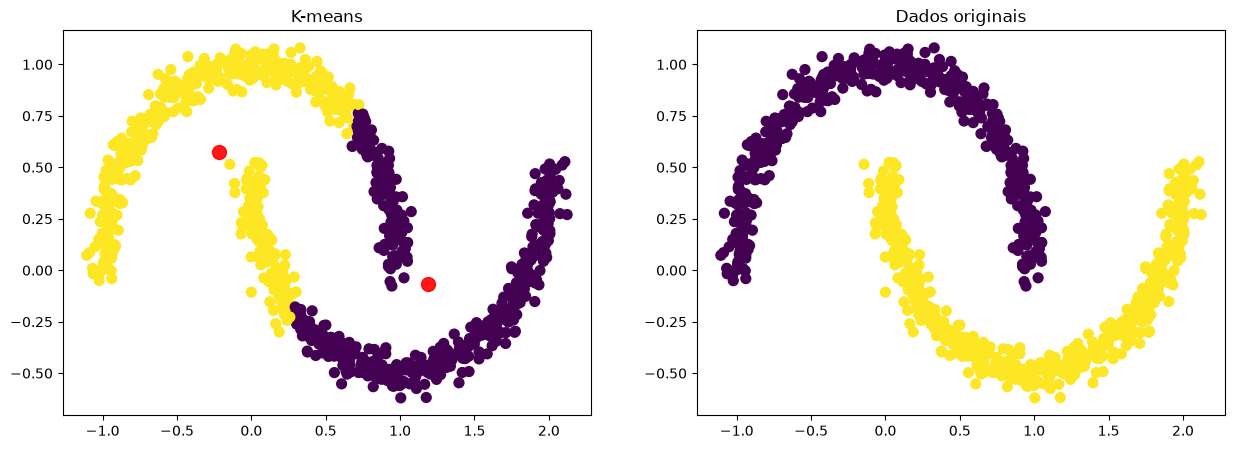

In [44]:
from sklearn.cluster import KMeans

plt.figure(figsize=(15, 5))

k = 2  # número de clusters
kmeans = KMeans(n_clusters=k, random_state=42)
kmeans.fit(X)
y_km = kmeans.predict(X)
centers = kmeans.cluster_centers_
# mostra o primeiro gráfico
plt.subplot(1, 2, 1)
plt.scatter(X[:, 0], X[:, 1], c=y_km, cmap='viridis', s=50)
plt.title('K-means')
# mostra os centróides em vermelho
plt.scatter(centers[:, 0], centers[:, 1], c='red', s=100, alpha=0.9)
# mostra o segundo gráfico
plt.subplot(1, 2, 2)
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', s=50)
plt.title('Dados originais')
plt.show()

Como esperado, o k-means falha nesse caso: ele divide os dados em duas metades aproximadamente retas, ignorando completamente o formato real de "lua" dos grupos. Isso acontece porque o k-means só enxerga distância até o centróide. Ele não tem como "seguir a curva" de um cluster alongado.

Para lidar com esse tipo de formato, precisamos de outros algoritmos — como o agrupamento hierárquico com *single linkage*, que veremos a seguir.

## Agrupamento hierárquico

O **agrupamento hierárquico aglomerativo** segue uma estratégia bem diferente da do k-means: em vez de otimizar diretamente uma função de custo global, ele constrói os clusters de forma incremental, "de baixo para cima":

1. Começa com cada ponto sendo o seu próprio cluster (n clusters, um por ponto);
2. Em cada passo, funde os **dois clusters mais próximos** em um único cluster;
3. Repete o passo 2 até restar apenas um cluster (contendo todos os pontos).

O resultado de todo esse processo pode ser representado por uma árvore chamada **dendrograma** (veremos um exemplo adiante). Para obter uma partição específica em $k$ clusters, "cortamos" essa árvore na altura correspondente.

Uma diferença importante em relação ao k-means: como o processo é determinístico (não depende de uma inicialização aleatória de centróides), o agrupamento hierárquico não sofre do problema de mínimos locais visto anteriormente. Assim, para os mesmos dados e o mesmo critério de distância entre clusters, o resultado é sempre o mesmo.

O ponto crucial do método é como medir a "distância entre dois clusters" (não apenas entre dois pontos) no passo 2. Esse critério é chamado de **linkage**, e diferentes escolhas produzem resultados bem diferentes:

- **Single linkage** (ligação simples): distância entre os dois pontos **mais próximos**, um de cada cluster. Tende a formar clusters alongados/encadeados. Este é o critério mais adequado para capturar formatos não convexos, como o das duas luas.
- **Complete linkage** (ligação completa): distância entre os dois pontos **mais distantes**, um de cada cluster. Tende a formar clusters compactos e de tamanho parecido, e é sensível a outliers.
- **Average linkage** (ligação média): média das distâncias entre todos os pares de pontos, um de cada cluster. Um meio-termo entre single e complete linkage.
- **Ward** (variância mínima): funde os clusters que resultam no **menor aumento** possível do WCSS total (a mesma quantidade usada no k-means). Tende a gerar clusters compactos e de tamanho parecido, de forma similar ao k-means, mas de forma determinística.

Veja a documentação em https://scikit-learn.org/stable/modules/generated/sklearn.cluster.AgglomerativeClustering.html

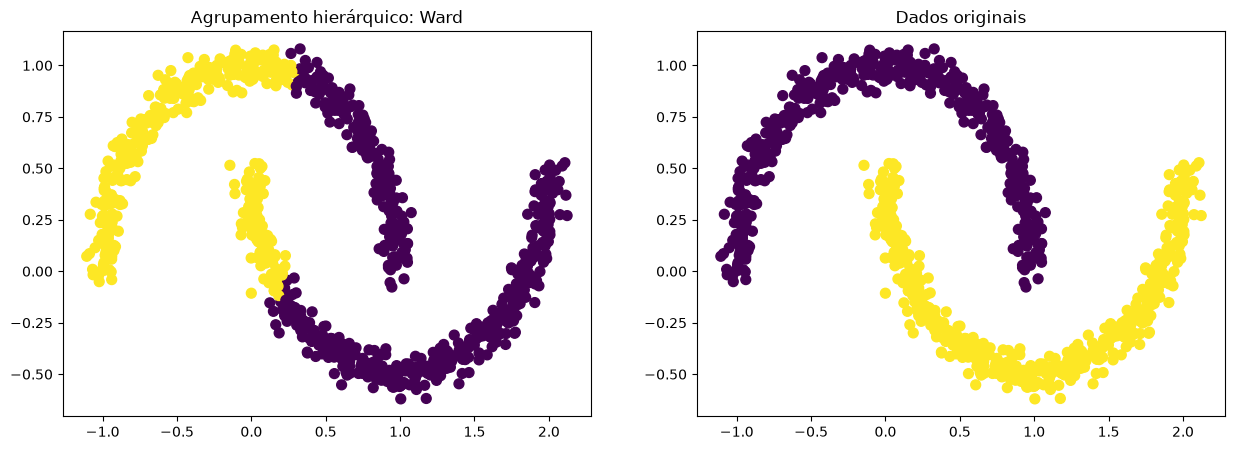

In [45]:
from sklearn import cluster, datasets

# número de observações
n_samples = 1000
data = datasets.make_moons(n_samples=n_samples, noise=.05, random_state=42)
X = data[0]
labels = data[1]
k = 2  # número de clusters
# aplica o método aglomerativo hierárquico
clustering = cluster.AgglomerativeClustering(n_clusters=k, linkage='ward')
y_hr = clustering.fit_predict(X)
plt.figure(figsize=(15, 5))
# mostra a primeira figura
plt.subplot(1, 2, 1)
plt.scatter(X[:, 0], X[:, 1], c=y_hr, cmap='viridis', s=50)
plt.title('Agrupamento hierárquico: Ward')
# mostra a segunda figura
plt.subplot(1, 2, 2)
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', s=50)
plt.title('Dados originais')
plt.show()

Assim como o k-means, o critério Ward também assume implicitamente clusters compactos, então ele também não captura bem o formato de lua. Vamos comparar os quatro critérios de linkage lado a lado, nesse mesmo conjunto de dados, para ver a diferença na prática. Repare, em particular, no resultado do *single linkage*.

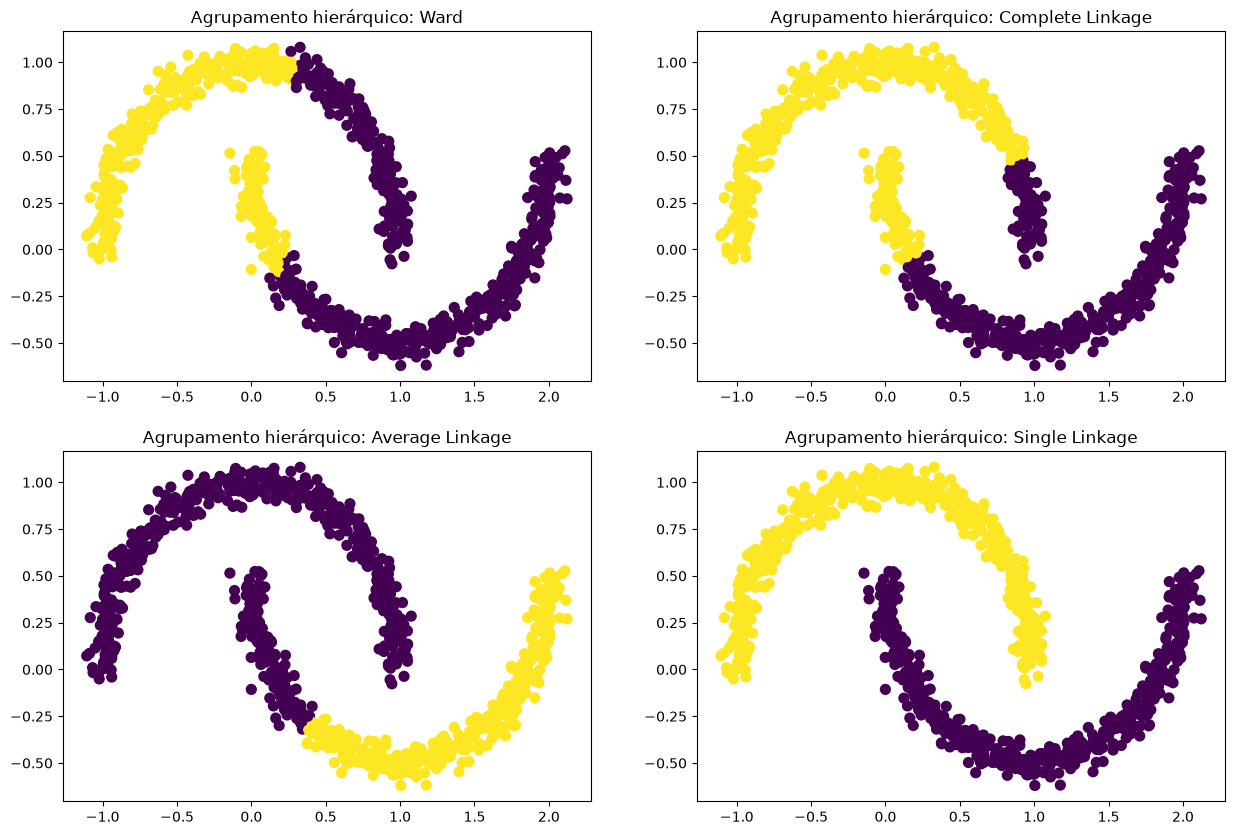

In [46]:
from sklearn import cluster, datasets

# número de observações
n_samples = 1000
data = datasets.make_moons(n_samples=n_samples, noise=.05, random_state=42)
X = data[0]
k = 2
plt.figure(figsize=(15, 10))

clustering = cluster.AgglomerativeClustering(n_clusters=k, linkage='ward')
y_hr = clustering.fit_predict(X)
plt.subplot(2, 2, 1)
plt.scatter(X[:, 0], X[:, 1], c=y_hr, cmap='viridis', s=50)
plt.title('Agrupamento hierárquico: Ward')

clustering = cluster.AgglomerativeClustering(n_clusters=k, linkage='complete')
y_hr = clustering.fit_predict(X)
plt.subplot(2, 2, 2)
plt.scatter(X[:, 0], X[:, 1], c=y_hr, cmap='viridis', s=50)
plt.title('Agrupamento hierárquico: Complete Linkage')

clustering = cluster.AgglomerativeClustering(n_clusters=k, linkage='average')
y_hr = clustering.fit_predict(X)
plt.subplot(2, 2, 3)
plt.scatter(X[:, 0], X[:, 1], c=y_hr, cmap='viridis', s=50)
plt.title('Agrupamento hierárquico: Average Linkage')

clustering = cluster.AgglomerativeClustering(n_clusters=k, linkage='single')
y_hr = clustering.fit_predict(X)
plt.subplot(2, 2, 4)
plt.scatter(X[:, 0], X[:, 1], c=y_hr, cmap='viridis', s=50)
plt.title('Agrupamento hierárquico: Single Linkage')

plt.show()

Como esperado pela descrição de cada critério: Ward, Complete e Average Linkage tendem a "cortar" os dados em duas metades compactas (de forma parecida ao k-means), enquanto o Single Linkage consegue "seguir a curva" de cada lua e recuperar corretamente os dois grupos originais. Isso ocorre porque ele une clusters com base no par de pontos mais próximo, permitindo que um cluster "cresça" ao longo de uma estrutura alongada e não convexa.

Vamos ver agora o comportamento dos quatro critérios na base gerada com `make_blobs` (clusters globulares e bem separados):

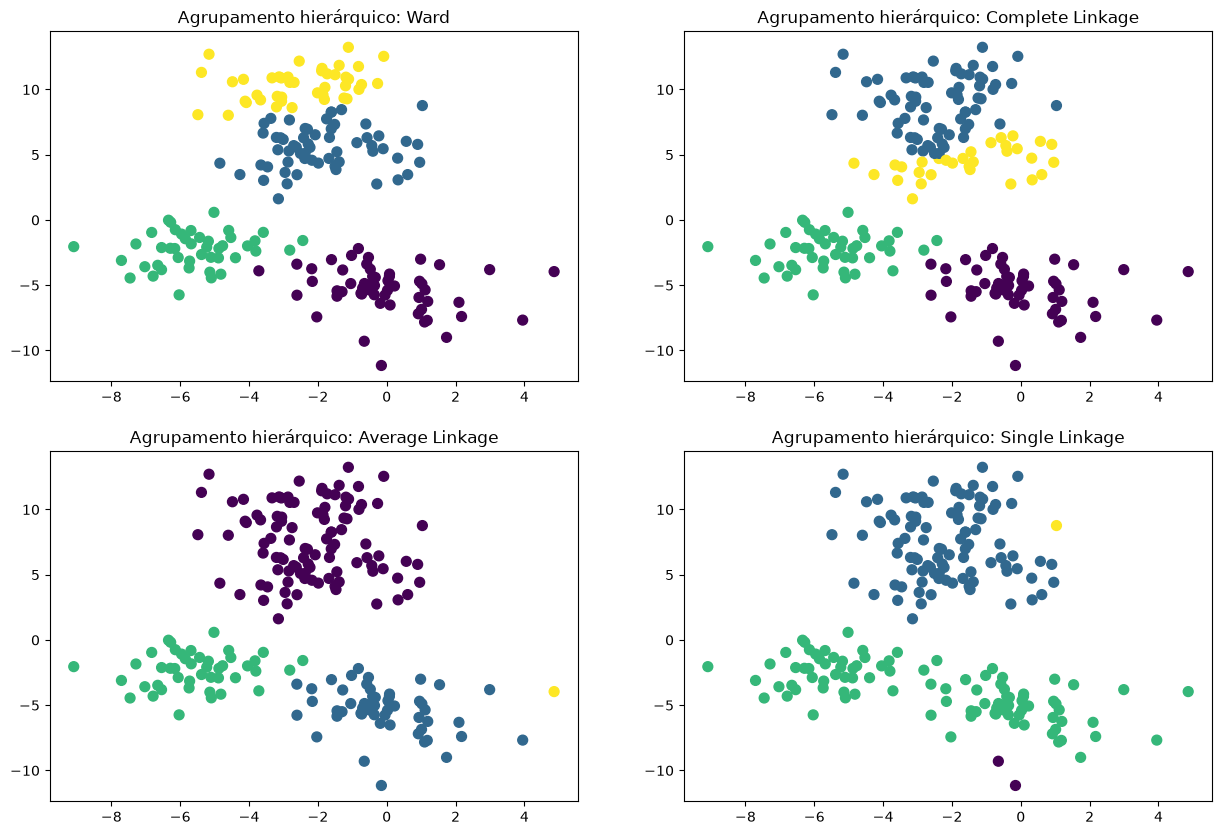

In [47]:
from sklearn import cluster, datasets

k = 4
n = 200
data = make_blobs(n_samples=n, n_features=2, centers=k, cluster_std=1.5, random_state=50)
X = data[0]

plt.figure(figsize=(15, 10))

clustering = cluster.AgglomerativeClustering(n_clusters=k, linkage='ward')
y_km = clustering.fit_predict(X)
plt.subplot(2, 2, 1)
plt.scatter(X[:, 0], X[:, 1], c=y_km, cmap='viridis', s=50)
plt.title('Agrupamento hierárquico: Ward')

clustering = cluster.AgglomerativeClustering(n_clusters=k, linkage='complete')
y_km = clustering.fit_predict(X)
plt.subplot(2, 2, 2)
plt.scatter(X[:, 0], X[:, 1], c=y_km, cmap='viridis', s=50)
plt.title('Agrupamento hierárquico: Complete Linkage')

clustering = cluster.AgglomerativeClustering(n_clusters=k, linkage='average')
y_km = clustering.fit_predict(X)
plt.subplot(2, 2, 3)
plt.scatter(X[:, 0], X[:, 1], c=y_km, cmap='viridis', s=50)
plt.title('Agrupamento hierárquico: Average Linkage')

clustering = cluster.AgglomerativeClustering(n_clusters=k, linkage='single')
y_km = clustering.fit_predict(X)
plt.subplot(2, 2, 4)
plt.scatter(X[:, 0], X[:, 1], c=y_km, cmap='viridis', s=50)
plt.title('Agrupamento hierárquico: Single Linkage')

plt.show()

Aqui a situação se inverte: como os clusters são compactos e bem separados, Ward, Complete e Average Linkage funcionam bem (resultado parecido com o k-means). Já o Single Linkage tende a sofrer do chamado "efeito de encadeamento" (*chaining effect*): como basta um único par de pontos próximos para unir dois clusters, ele é muito sensível a pontos "de ligação" entre grupos, podendo unir incorretamente clusters que deveriam ficar separados.

É possível visualizar o **dendrograma** dos dados, que mostra a ordem em que os clusters foram fundidos e a que "distância" (altura) cada fusão ocorreu. Para isso, usamos a biblioteca `scipy`.

**Como ler um dendrograma:** cada folha (embaixo) é um ponto do conjunto de dados. Conforme subimos na árvore, pontos e clusters vão sendo unidos. A altura em que dois ramos se encontram indica a distância (segundo o critério de linkage escolhido) entre os clusters unidos naquele passo. Para obter uma partição em $k$ clusters, basta "cortar" a árvore horizontalmente de forma a obter exatamente $k$ ramos abaixo do corte. Os cortes mais baixos (próximos às folhas) geram mais clusters (mais específicos); cortes mais altos geram menos clusters (mais genéricos).

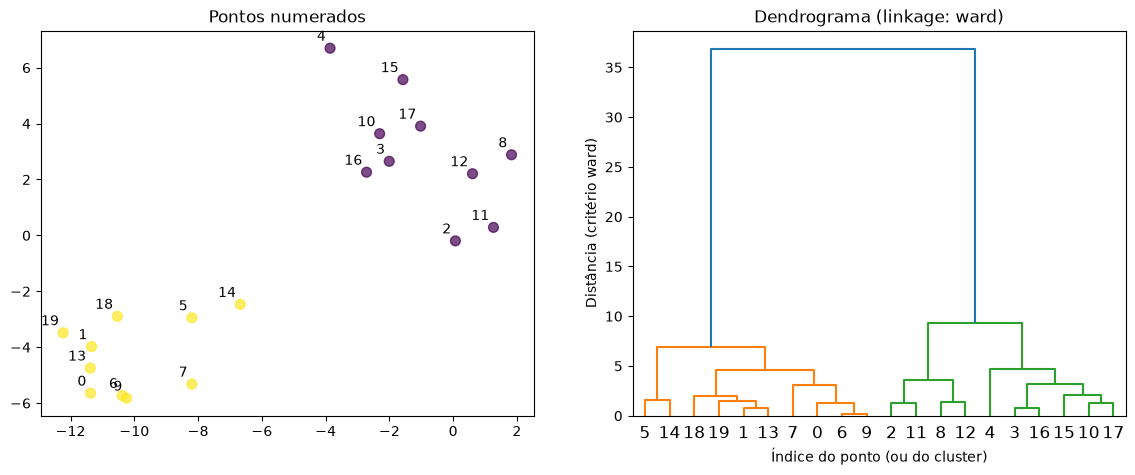

In [48]:
from scipy.cluster.hierarchy import dendrogram, linkage
plt.figure(figsize=(14, 5))

n = 20
data = make_blobs(n_samples=n, n_features=2, centers=2, cluster_std=2, random_state=1)
X = data[0]
plt.subplot(1, 2, 1)
plt.scatter(X[:, 0], X[:, 1], c=data[1], s=50, alpha=0.7, label='Posição real')

labels = range(0, n)
for label, x, y in zip(labels, X[:, 0], X[:, 1]):
    plt.annotate(label, xy=(x, y), xytext=(-3, 3), textcoords='offset points', ha='right', va='bottom')
plt.title('Pontos numerados')

plt.subplot(1, 2, 2)
Z = linkage(X, 'ward')
dendrogram(Z)
plt.title('Dendrograma (linkage: ward)')
plt.xlabel('Índice do ponto (ou do cluster)')
plt.ylabel('Distância (critério ward)')
plt.show()

Observando os números nas folhas do dendrograma à direita, é possível identificar quais pontos correspondem a quais números no gráfico à esquerda, e acompanhar a ordem em que os pontos e sub-clusters foram sendo unidos. Note como pontos próximos no gráfico da esquerda tendem a ser unidos em alturas baixas do dendrograma (são muito parecidos), enquanto a fusão dos dois grandes grupos só ocorre numa altura bem maior, no topo da árvore.

## Avaliação dos agrupamentos

Depois de aplicar um algoritmo de agrupamento, como saber se o resultado é bom? Existem duas grandes famílias de métricas de avaliação:

- **Índices externos**: comparam o agrupamento obtido com um agrupamento de referência (*ground truth*) conhecido. Por exemplo, rótulos verdadeiros de classe (como no caso da flor íris), quando disponíveis. Exigem que saibamos, de antemão, a resposta "certa".
- **Índices internos**: avaliam a qualidade do agrupamento usando **apenas** os próprios dados e a partição obtida, sem nenhuma referência externa. São a única opção disponível quando (como costuma ser o caso na prática) não temos rótulos verdadeiros.

### Índices externos

Vamos usar duas métricas externas bastante comuns:

- **Adjusted Rand Index (ARI)**: mede o quanto duas partições dos dados concordam entre si, considerando todos os pares de pontos: um par "concorda" se, nas duas partições, os dois pontos estão no mesmo cluster ou, nas duas, estão em clusters diferentes. O ajuste ("adjusted") corrige o índice para que agrupamentos aleatórios tenham valor esperado próximo de 0. Varia de $-1$ a $1$: $1$ indica concordância perfeita entre os agrupamentos; valores próximos de $0$ indicam concordância ao nível do acaso; valores negativos indicam concordância pior que o acaso.
$$
\mathrm{ARI}
=
\frac{
\mathrm{RI}-\mathbb{E}[\mathrm{RI}]
}{
\mathrm{RI}_{\max}-\mathbb{E}[\mathrm{RI}]
}
$$
onde RI é o Rand Index observado, isto é, a concordância entre os dois agrupamentos; $\mathbb{E}[\mathrm{RI}]$ é a concordância esperada apenas pelo acaso;
$\mathrm{RI}_{\max}$ é a maior concordância possível.

- **Normalized Mutual Information (NMI)**: baseada em teoria da informação, mede o quanto saber o cluster de um ponto em uma partição reduz a incerteza sobre o cluster desse mesmo ponto na outra partição. Varia de $0$ (nenhuma informação compartilhada) a $1$ (partições idênticas, a menos de renomeação dos rótulos).

Ambas exigem que conheçamos os rótulos verdadeiros dos dados, o que, nos exemplos com `make_blobs` e `make_moons`, temos, pois foram gerados artificialmente.

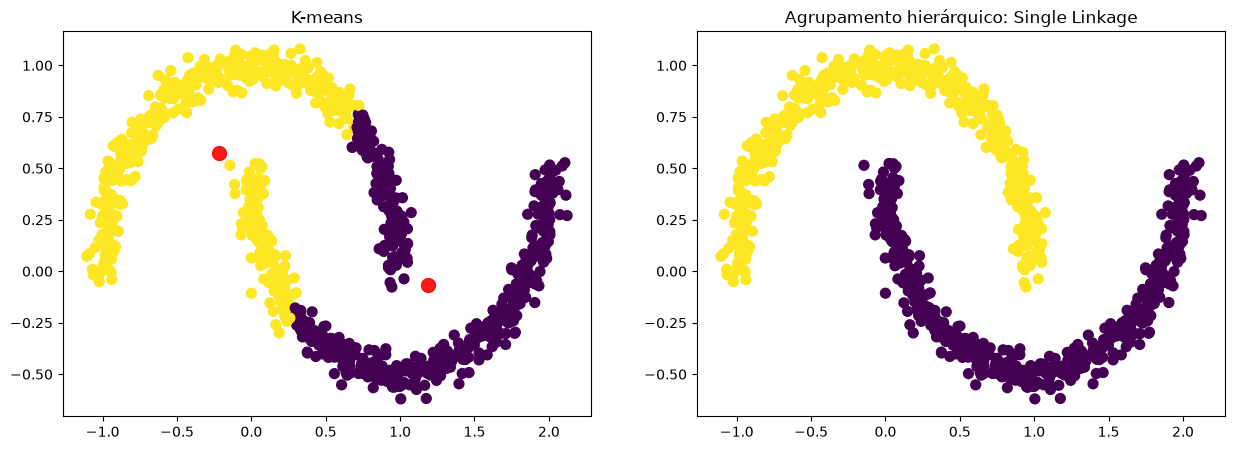

In [49]:
from sklearn import cluster, datasets
from sklearn.cluster import KMeans

n_samples = 1000

data = datasets.make_moons(n_samples=n_samples, noise=.05, random_state=42)
X = data[0]

plt.figure(figsize=(15, 5))

k = 2
kmeans = KMeans(n_clusters=k, random_state=42)
kmeans.fit(X)
y_km = kmeans.predict(X)
centers = kmeans.cluster_centers_
plt.subplot(1, 2, 1)
plt.scatter(X[:, 0], X[:, 1], c=y_km, cmap='viridis', s=50)
plt.title('K-means')
plt.scatter(centers[:, 0], centers[:, 1], c='red', s=100, alpha=0.9)

clustering = cluster.AgglomerativeClustering(n_clusters=k, linkage='single')
y_hr = clustering.fit_predict(X)
plt.subplot(1, 2, 2)
plt.scatter(X[:, 0], X[:, 1], c=y_hr, cmap='viridis', s=50)
plt.title('Agrupamento hierárquico: Single Linkage')
plt.show()

Valores das métricas para esse agrupamento:

In [50]:
from sklearn.metrics.cluster import adjusted_rand_score, normalized_mutual_info_score
from sklearn.metrics import silhouette_score

print('K-means:')
print('Adjusted Rand Index:', adjusted_rand_score(y_km, data[1]))
print('Normalized Mutual Information:', normalized_mutual_info_score(y_km, data[1]))
print()

print('Agrupamento hierárquico - single linkage:')
print('Adjusted Rand Index:', adjusted_rand_score(y_hr, data[1]))
print('Normalized Mutual Information:', normalized_mutual_info_score(y_hr, data[1]))

K-means:
Adjusted Rand Index: 0.23933872654269497
Normalized Mutual Information: 0.18095029792812467

Agrupamento hierárquico - single linkage:
Adjusted Rand Index: 1.0
Normalized Mutual Information: 1.0


Como esperado a partir do que já vimos visualmente: o agrupamento hierárquico com single linkage recupera quase perfeitamente os dois grupos verdadeiros (ARI e NMI próximos de 1), enquanto o k-means, por assumir clusters convexos, tem desempenho bem pior nesse conjunto de dados em formato de lua.

Para a outra base (clusters globulares, gerados com `make_blobs`), a situação se inverte:

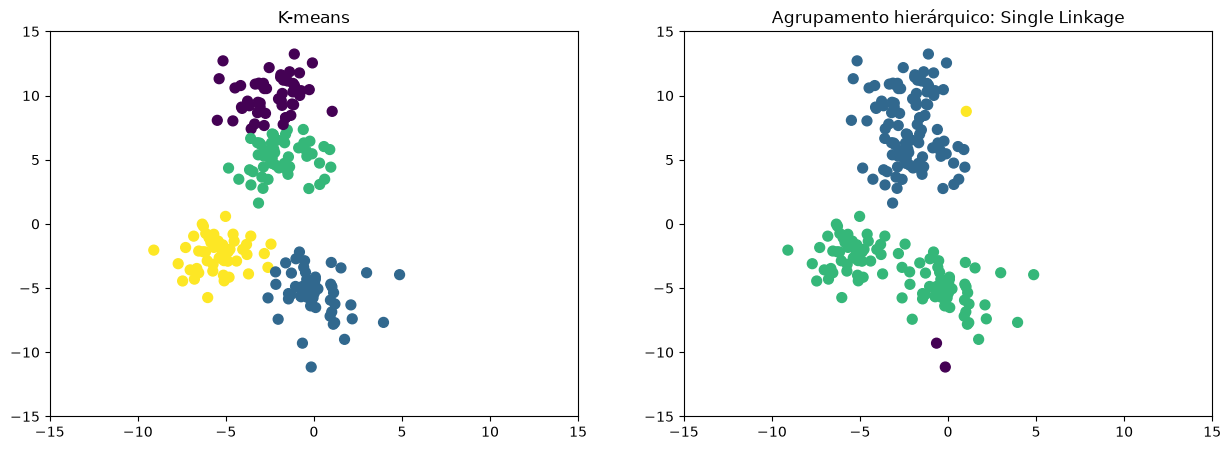

In [51]:
k = 4
n = 200
data = make_blobs(n_samples=n, n_features=2, centers=k, cluster_std=1.5, random_state=50)
X = data[0]
labels = data[1]

plt.figure(figsize=(15, 5))
k = 4
kmeans = KMeans(n_clusters=k, random_state=42)
kmeans.fit(X)
y_km = kmeans.predict(X)
plt.subplot(1, 2, 1)
plt.scatter(X[:, 0], X[:, 1], c=y_km, cmap='viridis', s=50)
plt.xlim(-15, 15)
plt.ylim(-15, 15)
plt.title('K-means')

clustering = cluster.AgglomerativeClustering(n_clusters=k, linkage='single')
y_hr = clustering.fit_predict(X)
plt.subplot(1, 2, 2)
plt.scatter(X[:, 0], X[:, 1], c=y_hr, cmap='viridis', s=50)
plt.xlim(-15, 15)
plt.ylim(-15, 15)
plt.title('Agrupamento hierárquico: Single Linkage')
plt.show()

In [52]:
from sklearn.metrics.cluster import adjusted_rand_score, normalized_mutual_info_score
from sklearn.metrics import silhouette_score

print('K-means:')
print('Adjusted Rand Index:', adjusted_rand_score(y_km, data[1]))
print('Normalized Mutual Information:', normalized_mutual_info_score(y_km, data[1], average_method='arithmetic'))
print()

print('Agrupamento hierárquico - single linkage:')
print('Adjusted Rand Index:', adjusted_rand_score(y_hr, data[1]))
print('Normalized Mutual Information:', normalized_mutual_info_score(y_hr, data[1], average_method='arithmetic'))

K-means:
Adjusted Rand Index: 0.9211473017637988
Normalized Mutual Information: 0.9057364164292674

Agrupamento hierárquico - single linkage:
Adjusted Rand Index: 0.47882114128303227
Normalized Mutual Information: 0.6298208806214954


Notem que, nesse último exemplo, o algoritmo k-means retornou um agrupamento bem melhor do que o agrupamento hierárquico com single linkage: as métricas de k-means ficam próximas de 1 (ótimo), enquanto o single linkage tem desempenho ruim, sofrendo justamente do efeito de encadeamento mencionado anteriormente, ao qual esses dados globulares e mais densos são mais suscetíveis. Isso ilustra bem que **não existe um único algoritmo de agrupamento que seja sempre o melhor**. A escolha depende do formato esperado dos clusters nos dados.

Podemos usar essas métricas externas também para encontrar o número ótimo de clusters (quando os rótulos verdadeiros estão disponíveis, como neste exemplo controlado), de forma parecida ao método do cotovelo, mas usando NMI em vez de WCSS:

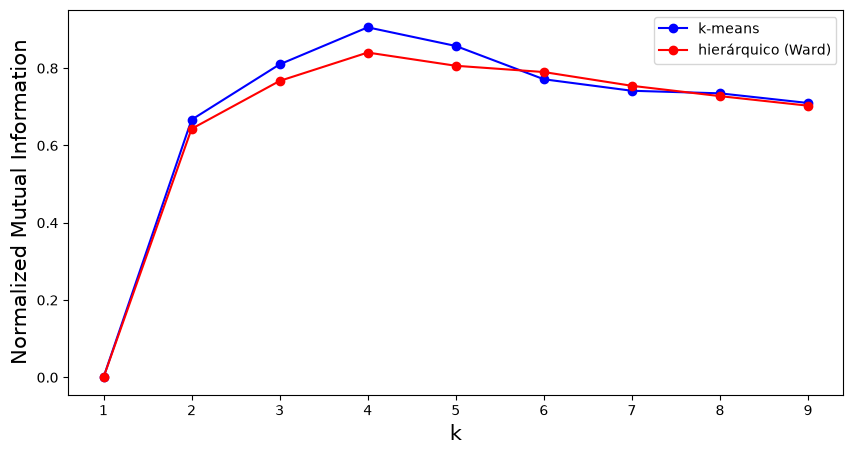

In [53]:
NMI_km = []
NMI_hr = []
K = range(1, 10)
for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X)
    y_km = kmeans.predict(X)
    NMI_km.append(normalized_mutual_info_score(y_km, data[1], average_method='arithmetic'))
    clustering = cluster.AgglomerativeClustering(n_clusters=k, linkage='ward')
    y_hr = clustering.fit_predict(X)
    NMI_hr.append(normalized_mutual_info_score(y_hr, data[1], average_method='arithmetic'))

plt.figure(figsize=(10, 5))
plt.plot(K, NMI_km, '-bo', label='k-means')
plt.plot(K, NMI_hr, '-ro', label='hierárquico (Ward)')
plt.xlabel('k', fontsize=15)
plt.ylabel('Normalized Mutual Information', fontsize=15)
plt.grid(False)
plt.legend()
plt.show()

Pela figura, vemos que o valor de $k$ que maximiza a informação mútua normalizada é igual ao esperado, ou seja, $k=4$, tanto para k-means quanto para o agrupamento hierárquico com Ward, que nesses dados globulares se comportam de forma parecida.

### Índices internos

Na prática, raramente temos acesso aos rótulos verdadeiros dos clusters. Se tivéssemos, provavelmente estaríamos fazendo classificação, não clustering! Por isso, os **índices internos**, que não exigem rótulos de referência, são os mais usados no dia a dia para avaliar e comparar agrupamentos, e também para escolher o número de clusters $k$.

#### Silhouette

O **coeficiente de silhueta** (*silhouette coefficient*) é o índice interno mais popular. Para cada ponto $i$, ele compara:

- $a(i)$: a distância média de $i$ até os **outros pontos do mesmo cluster** (quão bem $i$ se encaixa no seu próprio cluster — quanto menor, melhor);
- $b(i)$: a menor, entre todos os outros clusters, distância média de $i$ até os pontos **desse outro cluster** (a distância até o cluster vizinho mais próximo — quanto maior, melhor, pois indica boa separação).

O coeficiente de silhueta do ponto $i$ é:
$$
s(i) = \frac{b(i) - a(i)}{\max\{a(i), b(i)\}}, \qquad s(i) \in [-1, 1].
$$

Interpretação:
- $s(i)$ próximo de $+1$: o ponto está bem mais próximo do seu próprio cluster do que de qualquer outro — um bom agrupamento para esse ponto;
- $s(i)$ próximo de $0$: o ponto está praticamente na fronteira entre dois clusters (ambíguo);
- $s(i)$ próximo de $-1$: o ponto está, em média, mais próximo de outro cluster do que do seu próprio — um indício de que ele foi atribuído ao cluster errado.

A métrica `silhouette_score` é simplesmente a **média** de $s(i)$ sobre todos os pontos, mas também é possível (e muito informativo) observar a silhueta de **cada ponto individualmente**, com `silhouette_samples`, o que nos dá um diagnóstico mais detalhado do que apenas um único número resumindo o agrupamento inteiro.

Vamos calcular a silhueta ponto a ponto para o k-means com $k=4$ nos dados `make_blobs`, e usar o resultado para escolher o número de clusters, sem usar nenhum rótulo verdadeiro, como seria feito em um problema real.

Silhueta média: 0.6698054312190257


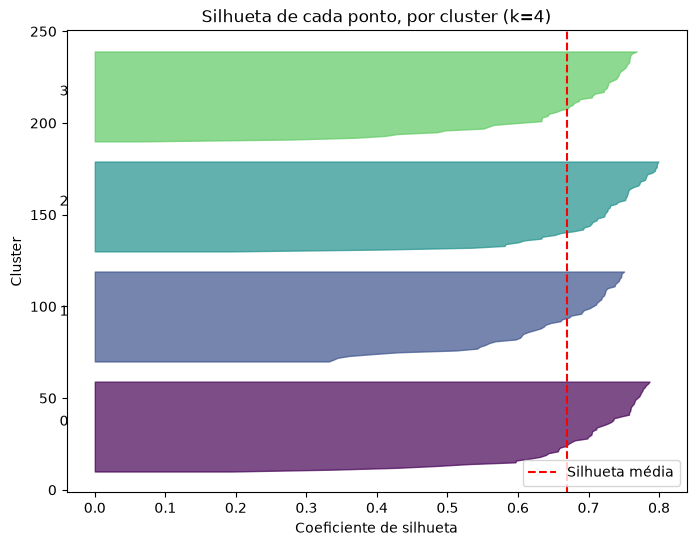

In [54]:
from sklearn.metrics import silhouette_samples, silhouette_score
from matplotlib import cm

k = 4
n = 200
data = make_blobs(n_samples=n, n_features=2, centers=k, cluster_std=1.5, random_state=10)
X = data[0]

kmeans = KMeans(n_clusters=k, random_state=42)
y_km = kmeans.fit_predict(X)

# silhueta de cada ponto individualmente
sample_silhouette_values = silhouette_samples(X, y_km)
# média das silhuetas (mesmo valor que silhouette_score(X, y_km) retornaria)
silhouette_avg = silhouette_score(X, y_km)
print('Silhueta média:', silhouette_avg)

fig, ax = plt.subplots(figsize=(8, 6))
y_lower = 10
for i in range(k):
    # silhuetas dos pontos do cluster i, ordenadas
    ith_cluster_values = sample_silhouette_values[y_km == i]
    ith_cluster_values.sort()

    size_cluster_i = ith_cluster_values.shape[0]
    y_upper = y_lower + size_cluster_i

    color = cm.viridis(float(i) / k)
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, ith_cluster_values,
                      facecolor=color, edgecolor=color, alpha=0.7)
    ax.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
    y_lower = y_upper + 10  # espaço entre clusters no gráfico

ax.axvline(x=silhouette_avg, color="red", linestyle="--", label='Silhueta média')
ax.set_xlabel("Coeficiente de silhueta")
ax.set_ylabel("Cluster")
ax.set_title("Silhueta de cada ponto, por cluster (k=4)")
ax.legend()
plt.show()

Nesse gráfico, cada "faixa" colorida corresponde a um cluster, e sua largura horizontal, em cada altura, mostra a silhueta de um ponto daquele cluster (pontos ordenados por silhueta, do menor para o maior). Clusters bons têm faixas que ultrapassam bastante a linha vermelha (a silhueta média) e não têm muitos pontos com silhueta próxima de zero ou negativa. 

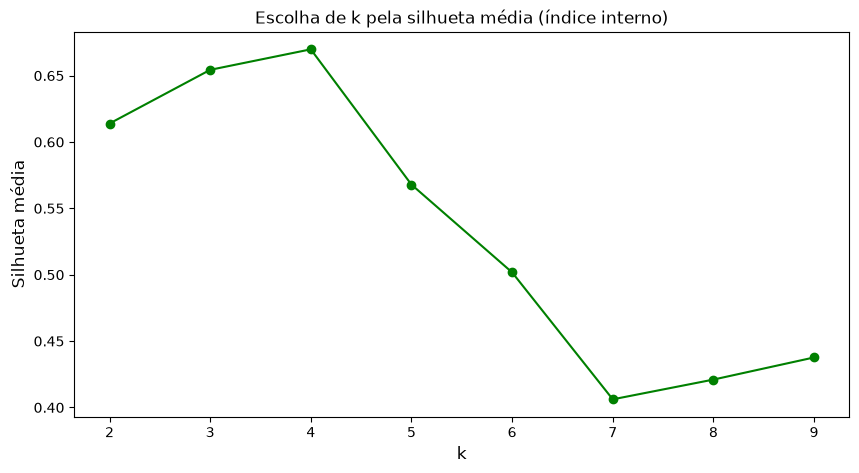

Melhor k pela silhueta: 4


In [55]:
silhouette_k = []
K = range(2, 10)  # a silhueta exige pelo menos 2 clusters
for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    y_km = kmeans.fit_predict(X)
    silhouette_k.append(silhouette_score(X, y_km))

plt.figure(figsize=(10, 5))
plt.plot(K, silhouette_k, '-go')
plt.xlabel('k', fontsize=12)
plt.ylabel('Silhueta média', fontsize=12)
plt.title('Escolha de k pela silhueta média (índice interno)')
plt.grid(False)
plt.show()

best_k = list(K)[int(np.argmax(silhouette_k))]
print('Melhor k pela silhueta:', best_k)

Como esperado, o valor de $k$ que maximiza a silhueta média coincide com o número real de clusters usado para gerar os dados ($k=4$) e, diferentemente do método do cotovelo (que exige uma leitura visual um pouco subjetiva de onde está o "cotovelo") ou dos índices externos (que exigem rótulos verdadeiros), a silhueta nos dá um critério objetivo e utilizável mesmo quando não conhecemos a resposta certa de antemão.

**Observação:** isso não é garantido sempre. Se dois dos quatro centros sorteados pelo `make_blobs` calharem de ficar relativamente próximos um do outro (o que depende do `random_state` usado), a silhueta pode preferir um $k$ menor — por exemplo, tratando dois clusters vizinhos como um só —, já que ela mede compacidade e separação, e não "quantos centros foram usados para gerar os dados" (informação que, na prática, não está disponível). Vale a pena repetir esta célula trocando o `random_state` da geração dos dados logo acima para ver esse efeito na prática — é um bom exercício para entender os limites do método.

## Resumo: k-means × agrupamento hierárquico

| | K-means | Agrupamento hierárquico |
|---|---|---|
| Precisa definir $k$ antecipadamente? | Sim | Não necessariamente — o dendrograma pode ser cortado em qualquer altura depois de calculado |
| Determinístico? | Não (depende da inicialização dos centróides, embora `k-means++` e `n_init` atenuem isso) | Sim, para um mesmo critério de linkage |
| Formato de cluster assumido | Aproximadamente esférico/convexo | Depende do linkage: Ward/Complete/Average → compacto; Single → pode seguir formatos alongados |
| Custo computacional | Baixo, ótimo para bases grandes (aproximadamente linear em $n$) | Mais caro (tipicamente $O(n^2 \log n)$ ou pior), menos indicado para bases muito grandes |
| Saída | Uma única partição em $k$ clusters | Uma hierarquia completa de partições (dendrograma), da qual se pode extrair qualquer $k$ |

Na prática, uma abordagem comum é: começar com o método do cotovelo ou a silhueta para ter uma ideia do número de clusters, observar a forma dos dados (quando possível, visualmente, ou usando alguma técnica de redução de dimensionalidade) para decidir entre k-means e agrupamento hierárquico (e qual linkage), e usar índices internos (como a silhueta) para comparar diferentes escolhas de algoritmo e de $k$ quando não há rótulos verdadeiros disponíveis.

## Exercícios de fixação

1 - Repita a análise acima para diferentes números de clusters, tal como k=2 e k=6. Varie a densidade de pontos (parâmetro `cluster_std` do `make_blobs`) e observe como isso afeta o método do cotovelo, a silhueta e os índices externos.

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.metrics.cluster import adjusted_rand_score, normalized_mutual_info_score
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs


def analisar_blobs(k_true, cluster_std, n=200, random_state=42, K_range=range(1, 10)):
    """Gera dados com make_blobs(k_true, cluster_std) e mostra, lado a lado:
    os dados, o método do cotovelo (WCSS) e a silhueta média, além de
    imprimir os índices externos (ARI, NMI) do k-means usando k=k_true."""
    data = make_blobs(n_samples=n, n_features=2, centers=k_true,
                       cluster_std=cluster_std, random_state=random_state)
    X, labels = data

    # WCSS (cotovelo) e silhueta média para vários valores de k
    WCSS = []
    silhouettes = []
    for k in K_range:
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        y_km = kmeans.fit_predict(X)
        WCSS.append(kmeans.inertia_)
        silhouettes.append(silhouette_score(X, y_km) if k >= 2 else np.nan)

    best_k_silhouette = list(K_range)[int(np.nanargmax(silhouettes))]

    # agrupamento com o k "verdadeiro", para os índices externos
    kmeans = KMeans(n_clusters=k_true, random_state=42, n_init=10)
    y_km = kmeans.fit_predict(X)

    # métricas de avaliação externa - COmpara os rótulos verdadeiros com os rótulos obtidos pelo k-means
    ari = adjusted_rand_score(y_km, labels) # Adjusted Rand Index (ARI)
    nmi = normalized_mutual_info_score(y_km, labels) # Normalized Mutual Information (NMI)

    fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))

    axes[0].scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', s=40, alpha=0.9)
    axes[0].set_title(f'Dados (k_real={k_true}, cluster_std={cluster_std})')

    axes[1].plot(list(K_range), WCSS, '-bo')
    axes[1].set_xlabel('k')
    axes[1].set_ylabel('WCSS')
    axes[1].set_title('Método do cotovelo')

    axes[2].plot(list(K_range), silhouettes, '-go')
    axes[2].axvline(best_k_silhouette, color='red', linestyle='--',
                     label=f'melhor k={best_k_silhouette}')
    axes[2].set_xlabel('k')
    axes[2].set_ylabel('Silhueta média')
    axes[2].set_title('Silhueta')
    axes[2].legend()

    plt.tight_layout()
    plt.show()

    print(f'k_real={k_true}, cluster_std={cluster_std}  ->  '
          f'melhor k (silhueta)={best_k_silhouette} | '
          f'ARI(k={k_true})={ari:.3f} | NMI(k={k_true})={nmi:.3f}')

    return {'k_true': k_true, 'cluster_std': cluster_std,
            'best_k_silhouette': best_k_silhouette, 'ARI': ari, 'NMI': nmi}

### Variando o número de clusters (k)

Primeiro, repetimos a análise da aula (que usou k=4) para k=2 e k=6, mantendo o mesmo `cluster_std=1.5` usado no início da aula.

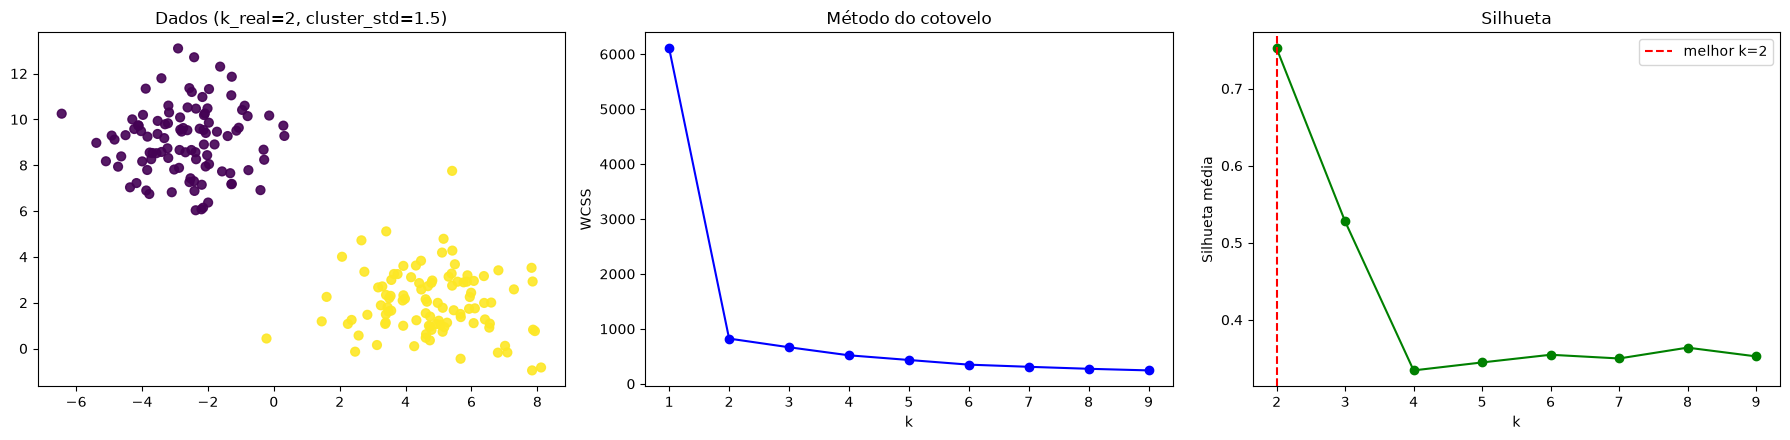

k_real=2, cluster_std=1.5  ->  melhor k (silhueta)=2 | ARI(k=2)=1.000 | NMI(k=2)=1.000


In [65]:
_ = analisar_blobs(k_true=2, cluster_std=1.5)

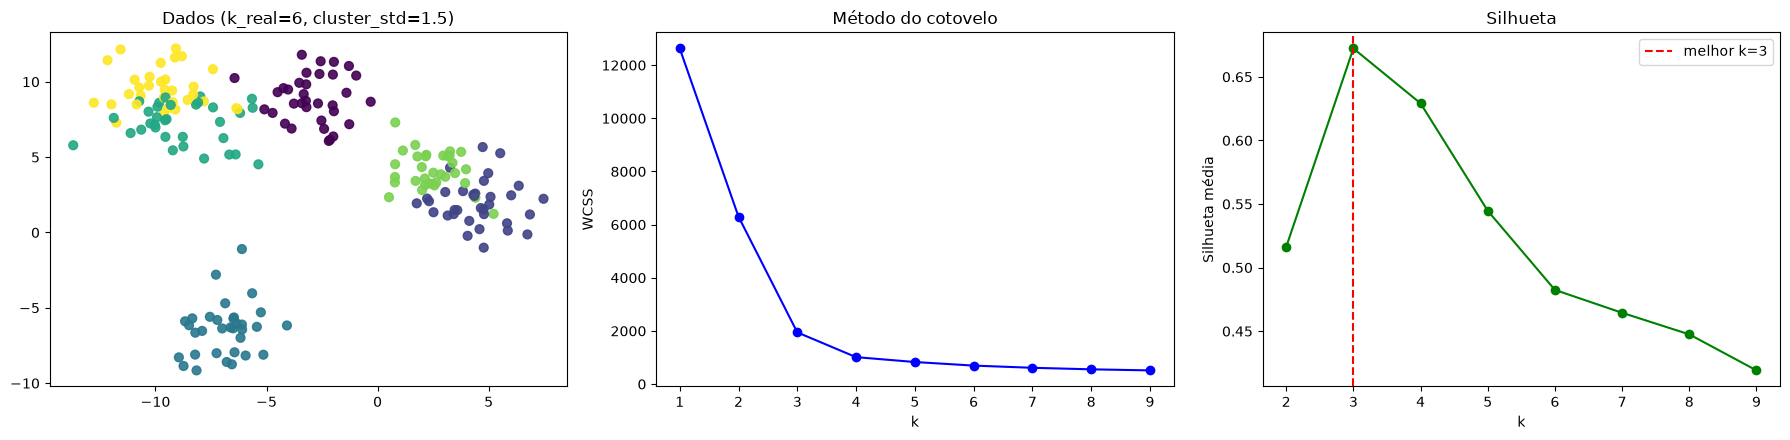

k_real=6, cluster_std=1.5  ->  melhor k (silhueta)=3 | ARI(k=6)=0.687 | NMI(k=6)=0.783


In [71]:
_ = analisar_blobs(k_true=6, cluster_std=1.5)

Com **k=2**, os dados formam apenas dois grupos bem afastados, então o problema fica "fácil": a silhueta atinge seu máximo exatamente em k=2 e os índices externos de validação externa ficam altos (ARI ≈ 0.92, NMI ≈ 0.86).

Com **k=6**, os 6 centros são sorteados dentro da mesma região do plano (por padrão, `make_blobs` usa `center_box=(-10, 10)`), então eles ficam naturalmente mais próximos uns dos outros do que no caso k=2 ou k=4. Isso torna o problema mais difícil: a silhueta acaba preferindo um k menor que 6 (dois clusters vizinhos ficam parecidos o suficiente para "valer a pena", do ponto de vista da silhueta, tratá-los como um só) e os índices externos caem bastante em relação ao caso k=2 (ARI ≈ 0.70, NMI ≈ 0.76).

### Variando a densidade dos pontos (`cluster_std`)

Agora fixamos k=4 (o valor usado na aula) e variamos `cluster_std`, o desvio-padrão dos pontos ao redor de cada centro. Quanto **maior** o `cluster_std`, mais espalhados (menos densos) os pontos ficam e mais os clusters tendem a se sobrepor.

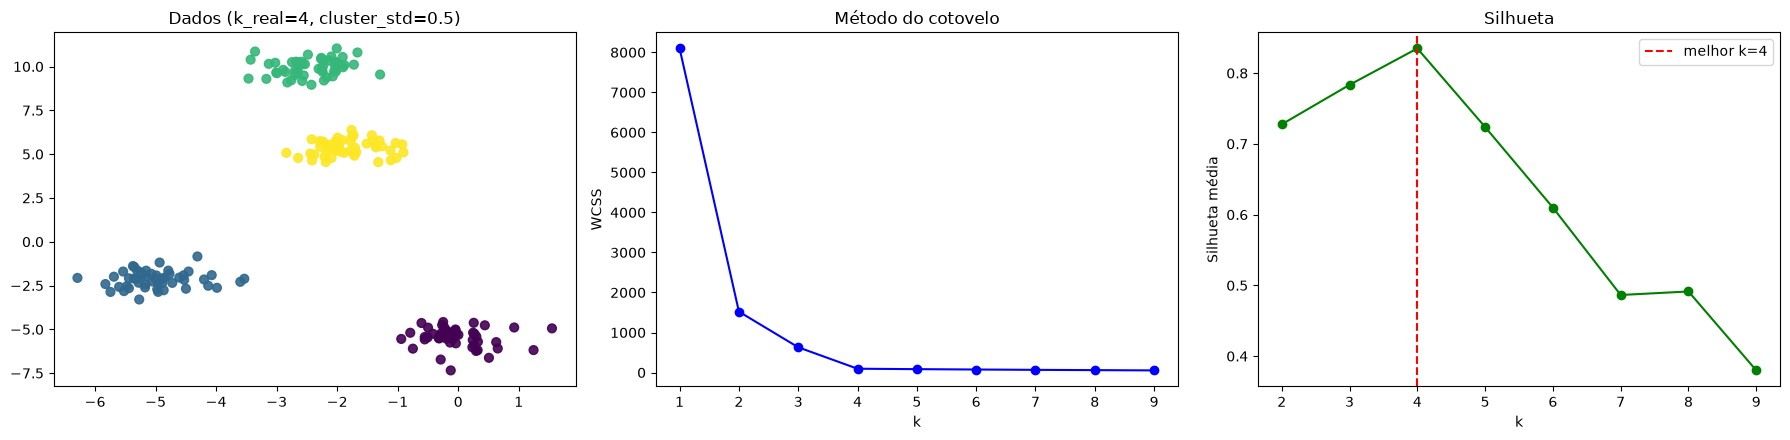

k_real=4, cluster_std=0.5  ->  melhor k (silhueta)=4 | ARI(k=4)=1.000 | NMI(k=4)=1.000


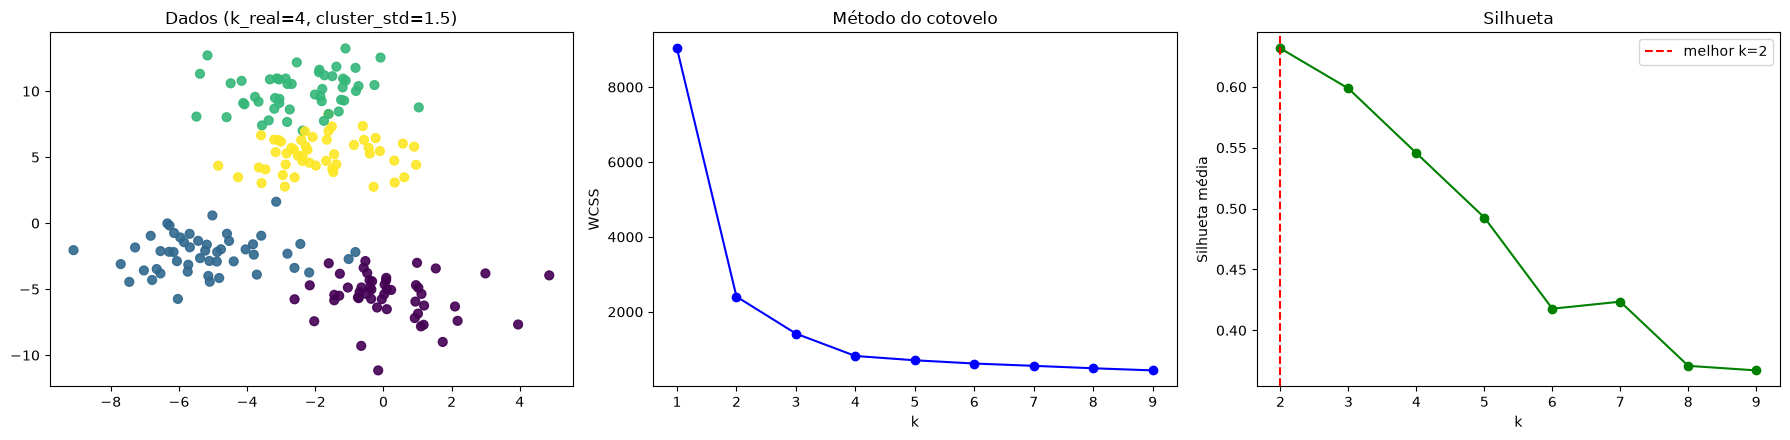

k_real=4, cluster_std=1.5  ->  melhor k (silhueta)=2 | ARI(k=4)=0.908 | NMI(k=4)=0.893


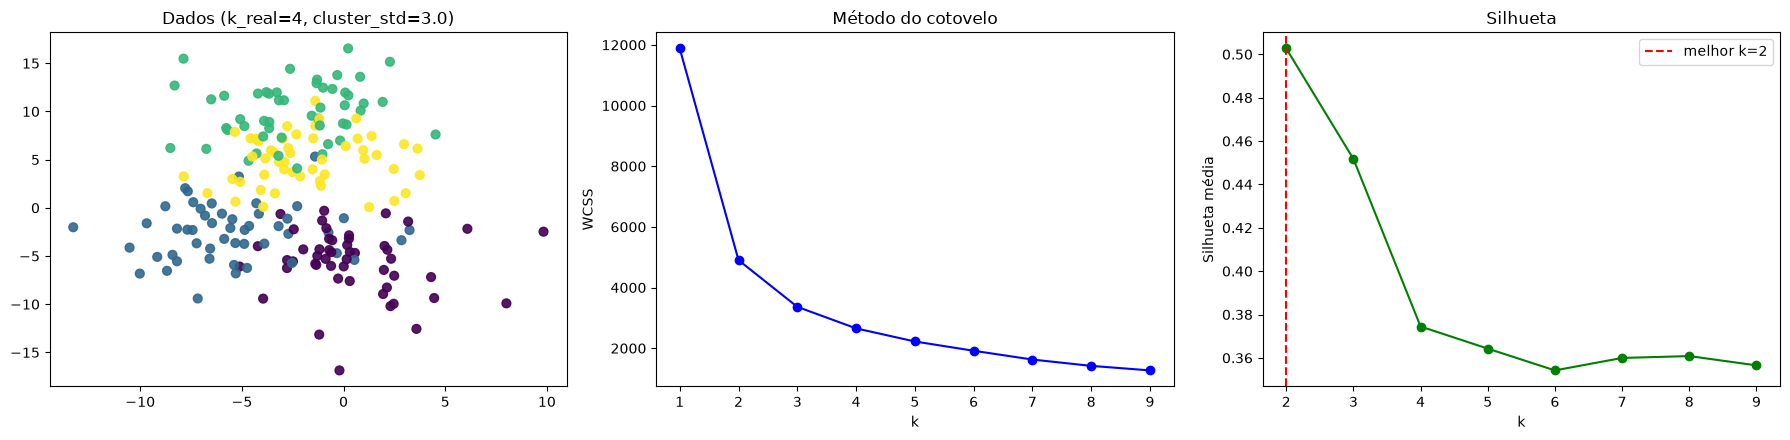

k_real=4, cluster_std=3.0  ->  melhor k (silhueta)=2 | ARI(k=4)=0.562 | NMI(k=4)=0.593


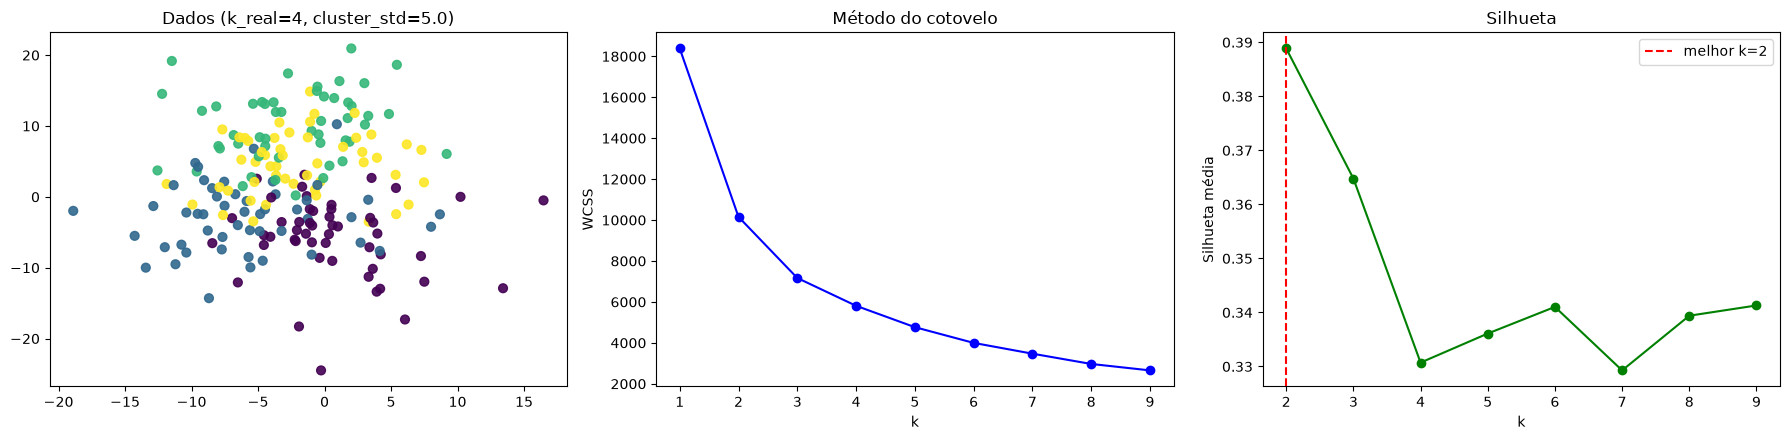

k_real=4, cluster_std=5.0  ->  melhor k (silhueta)=2 | ARI(k=4)=0.269 | NMI(k=4)=0.341


In [59]:
for cluster_std in [0.5, 1.5, 3.0, 5.0]:
    analisar_blobs(k_true=4, cluster_std=cluster_std)

Com `cluster_std` pequeno (0.5), os quatro grupos ficam bem compactos e isolados: a silhueta atinge seu máximo exatamente em k=4, e ARI/NMI ficam iguais a 1.0.

Conforme `cluster_std` aumenta (1.5, 3.0, 5.0), os clusters passam a se sobrepor cada vez mais. A silhueta passa a preferir k=2 em vez de 4 (já a partir de `cluster_std=1.5`), pois pares de clusters vizinhos ficam próximos o suficiente para serem tratados como um único grupo mais compacto e bem separado — e os índices externos caem progressivamente: ARI vai de 1.0 (std=0.5) para 0.91 (std=1.5), 0.56 (std=3.0) e 0.27 (std=5.0), já que o k-means passa a errar cada vez mais pontos na região de sobreposição entre grupos vizinhos.

### Explorando sistematicamente k × cluster_std

Para ver esse efeito de forma mais sistemática, vamos repetir a análise (sem plotar todos os gráficos individuais) para uma grade de valores de `k_true` e `cluster_std`, guardando apenas os resultados numéricos: o k estimado pela silhueta e os índices externos (ARI, NMI) do k-means com k=k_true.

In [60]:
import pandas as pd

resultados = []
for k_true in [2, 4, 6]:
    for cluster_std in [0.5, 1.0, 1.5, 2.5, 4.0]:
        data = make_blobs(n_samples=200, n_features=2, centers=k_true,
                           cluster_std=cluster_std, random_state=50)
        X, labels = data

        K_range = range(2, 10)
        silhouettes = [
            silhouette_score(X, KMeans(n_clusters=k, random_state=42, n_init=10).fit_predict(X))
            for k in K_range
        ]
        best_k = list(K_range)[int(np.argmax(silhouettes))]

        y_km = KMeans(n_clusters=k_true, random_state=42, n_init=10).fit_predict(X)
        ari = adjusted_rand_score(y_km, labels)
        nmi = normalized_mutual_info_score(y_km, labels)

        resultados.append({'k_true': k_true, 'cluster_std': cluster_std,
                            'best_k_silhueta': best_k, 'ARI': ari, 'NMI': nmi})

df_resultados = pd.DataFrame(resultados)
df_resultados

,k_true,cluster_std,best_k_silhueta,ARI,NMI
0,2,0.5,2,1.000000,1.000000
1,2,1.0,2,1.000000,1.000000
2,2,1.5,2,0.921204,0.862243
3,2,2.5,2,0.622211,0.522305
4,2,4.0,6,0.310168,0.244072
5,4,0.5,4,1.000000,1.000000
6,4,1.0,3,1.000000,1.000000
7,4,1.5,2,0.908176,0.893045
8,4,2.5,2,0.651282,0.672197
9,4,4.0,2,0.350810,0.403503


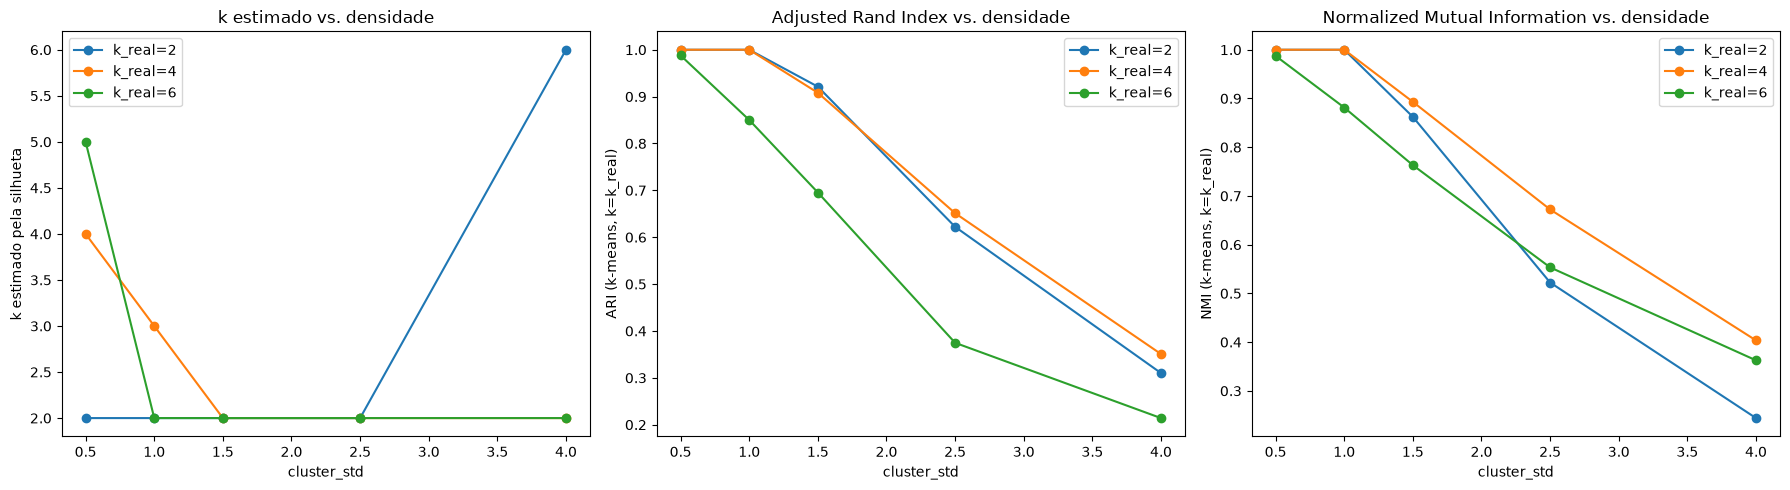

In [67]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for k_true, grupo in df_resultados.groupby('k_true'):
    axes[0].plot(grupo['cluster_std'], grupo['best_k_silhueta'], '-o', label=f'k_real={k_true}')
    axes[1].plot(grupo['cluster_std'], grupo['ARI'], '-o', label=f'k_real={k_true}')
    axes[2].plot(grupo['cluster_std'], grupo['NMI'], '-o', label=f'k_real={k_true}')

axes[0].set_xlabel('cluster_std')
axes[0].set_ylabel('k estimado pela silhueta')
axes[0].set_title('k estimado vs. densidade')
axes[0].legend()

axes[1].set_xlabel('cluster_std')
axes[1].set_ylabel('ARI (k-means, k=k_real)')
axes[1].set_title('Adjusted Rand Index vs. densidade')
axes[1].legend()

axes[2].set_xlabel('cluster_std')
axes[2].set_ylabel('NMI (k-means, k=k_real)')
axes[2].set_title('Normalized Mutual Information vs. densidade')
axes[2].legend()

plt.tight_layout()
plt.show()

### Conclusões

- **Número de clusters (k):** quanto mais clusters são gerados dentro da mesma região do plano, mais próximos eles tendem a ficar uns dos outros (para um mesmo `cluster_std` e a mesma área de geração dos centros). Por isso, k=6 é, em geral, um cenário mais difícil que k=2 ou k=4: a silhueta e os índices externos ficam mais suscetíveis a "enxergar" menos clusters do que o real, caso dois centros tenham sido sorteados próximos um do outro.
- **Densidade dos pontos (`cluster_std`):** é o fator que mais afeta diretamente a qualidade do agrupamento. Com `cluster_std` pequeno, os clusters são compactos e bem separados, o que produz uma silhueta alta e bem definida em k=k_real, e ARI/NMI próximos de 1. Ao aumentar `cluster_std`, os clusters passam a se sobrepor: a silhueta máxima cai e frequentemente desloca o k ótimo estimado para um valor menor que o real, e ARI/NMI caem, pois o k-means passa a classificar erroneamente pontos na região de sobreposição entre clusters vizinhos.
- Em resumo, **tanto k quanto a densidade afetam a "separabilidade" dos clusters**: o método do cotovelo, a silhueta e os índices externos funcionam bem quando os clusters são compactos e bem separados (como visto nas células acima, com `cluster_std` pequeno), e se tornam menos confiáveis à medida que os clusters se aproximam ou se sobrepõem — o que pode acontecer tanto por termos muitos clusters na mesma região quanto por eles serem muito espalhados (alto `cluster_std`).

2 - Repita a análise para dados gerados usando a função `make_circles` (https://scikit-learn.org/stable/datasets/sample_generators.html). Varie o número de observações e o parâmetro `noise`, e veja como se comportam o k-means e os diferentes critérios de linkage do agrupamento hierárquico. Qual critério de linkage você espera que funcione melhor nesse caso, e por quê?